In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import itertools

from scipy.stats import zscore

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from xgboost import XGBRegressor
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


In [35]:
# This data come from the following website:https://data.open-power-system-data.org/time_series/2020-10-06
# Which contains hourly electricity prices, consumption, and renewable generation data for the EU and neighbors (2015–mid 2020)

# We will start by cleaning and preparing the data for Belgium

#First step is to load the data, make sure everything is in date format and set the time as index as this is time series data
df = pd.read_csv('time_series_60min_singleindex.csv', parse_dates=['utc_timestamp'])
df.set_index('utc_timestamp', inplace=True)

In [36]:
# We will now select the relevant columns we want to study, so all the ones starting by BE

columns_to_keep = [col for col in df.columns if col.startswith("BE")] #using list comprehension to make a list of columns that start with "BE"
df = df[columns_to_keep]
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 50401 entries, 2014-12-31 23:00:00+00:00 to 2020-09-30 23:00:00+00:00
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   BE_load_actual_entsoe_transparency    50400 non-null  float64
 1   BE_load_forecast_entsoe_transparency  50376 non-null  float64
 2   BE_solar_generation_actual            50385 non-null  float64
 3   BE_wind_generation_actual             46466 non-null  float64
 4   BE_wind_offshore_generation_actual    46466 non-null  float64
 5   BE_wind_onshore_generation_actual     50398 non-null  float64
dtypes: float64(6)
memory usage: 2.7 MB


In [37]:
# We can observe from the df.head() that we have several columns with missing values, let's check how significant for each columns these NaN values are
# We will either get rid of a column if too many NaN or replace them with median values (let's consider 20% of NaN values too much to keep a column)

Nan_percentage = df.isna().mean()*100
Nan_percentage

# So we will be replacing NaN with median numbers, but we should first check if we don't have too many 0, which would impact our median number

BE_load_actual_entsoe_transparency      0.001984
BE_load_forecast_entsoe_transparency    0.049602
BE_solar_generation_actual              0.031745
BE_wind_generation_actual               7.807385
BE_wind_offshore_generation_actual      7.807385
BE_wind_onshore_generation_actual       0.005952
dtype: float64

In [38]:
# Count the number of 0 for each columns and get a percentage

zero_percentage = (df == 0).mean() * 100
zero_percentage

# This number of 0 could actually be explained by the time of day (night) and weather conditions, so we will keep them as they might be relevant

BE_load_actual_entsoe_transparency       0.000000
BE_load_forecast_entsoe_transparency     0.000000
BE_solar_generation_actual              45.001091
BE_wind_generation_actual                0.000000
BE_wind_offshore_generation_actual       0.003968
BE_wind_onshore_generation_actual        0.000000
dtype: float64

In [39]:
# Now let's test our hypothesis of solar generation being null at night

df['hour'] = df.index.hour
zero_by_hour = (df['BE_solar_generation_actual'] == 0).groupby(df['hour']).mean()*100
zero_by_hour

# As we can see, during daytime, we have no null values, but they do occur at night
# To match the pattern we will be replacing NaN values by 0 for nighttime (8PM to 2AM, because we have 99% of values = 0 for this interval)
# For the other Nan we will be using the median of the same hour plage
# I prefer using median as it is more robust to outliers, but we could also use mean or ffill(value after) and bfill(value before) for replacing NaN

hour
0     99.952381
1     99.952381
2     99.952381
3     84.047619
4     61.904762
5     43.380952
6     26.666667
7      0.571429
8      0.000000
9      0.000000
10     0.000000
11     0.047619
12     0.000000
13     0.000000
14     0.000000
15     0.000000
16    15.285714
17    32.761905
18    49.809524
19    68.380952
20    97.476190
21    99.952381
22    99.952381
23    99.904807
Name: BE_solar_generation_actual, dtype: float64

In [40]:
# Replacing NaN values 

for hour in range(24): # Iterate through the 24 hours
    median_value = df.loc[df['hour'] == hour, 'BE_solar_generation_actual'].median() # Get the median value for this hour
    
    if hour >= 20 or hour <= 2: # As we said, between 8PM and 2AM, value = O
        df.loc[(df['hour'] == hour) & (df['BE_solar_generation_actual'].isnull()), 'BE_solar_generation_actual'] = 0
    else: #other ones use the median of the same hour
        df.loc[(df['hour'] == hour) & (df['BE_solar_generation_actual'].isnull()), 'BE_solar_generation_actual'] = median_value

# For the other columns, we use median value if NaN
for col in df.columns:
    if col != 'BE_solar_generation_actual':  # Keep this column out of the loop as we already dealt with it
        df[col] = df[col].fillna(df[col].median())

df.isnull().sum()
# No NaN anymore

BE_load_actual_entsoe_transparency      0
BE_load_forecast_entsoe_transparency    0
BE_solar_generation_actual              0
BE_wind_generation_actual               0
BE_wind_offshore_generation_actual      0
BE_wind_onshore_generation_actual       0
hour                                    0
dtype: int64

<Figure size 1200x800 with 0 Axes>

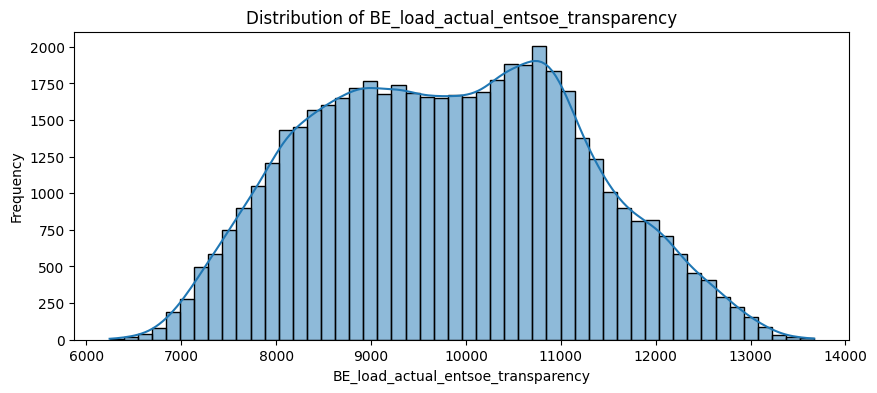

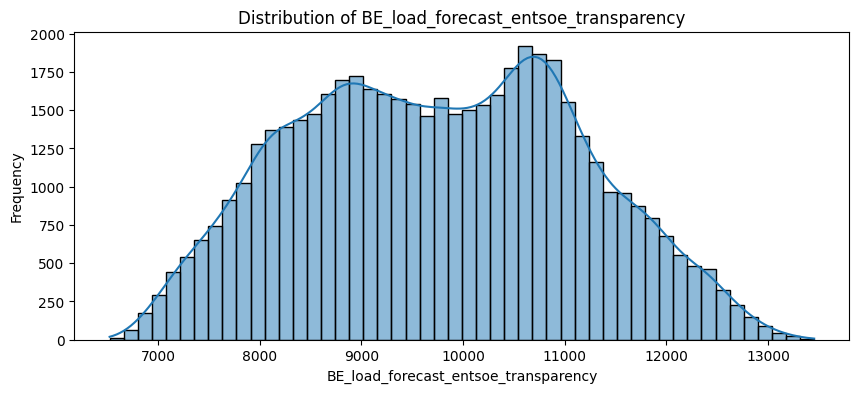

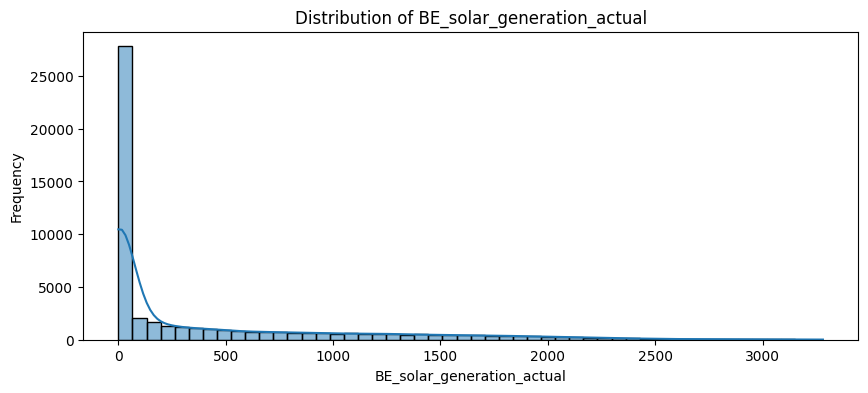

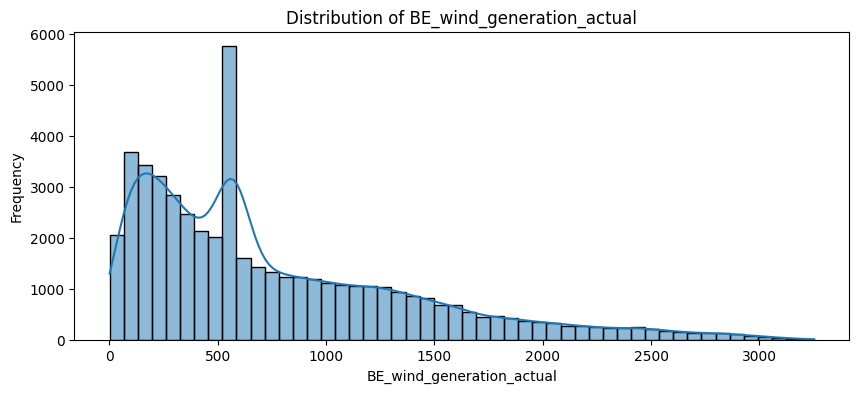

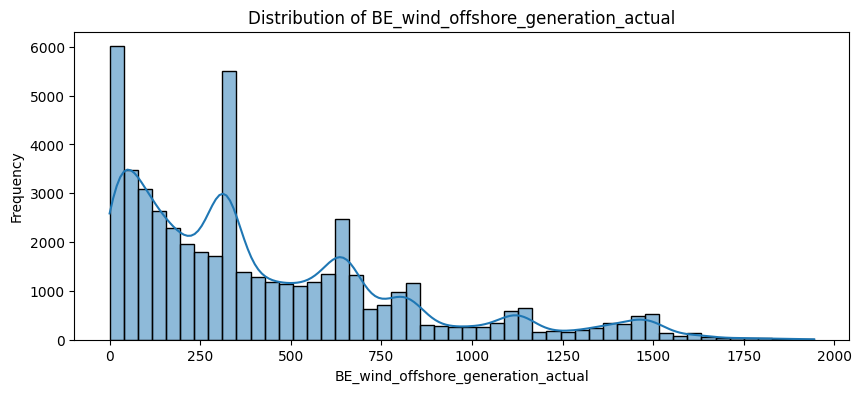

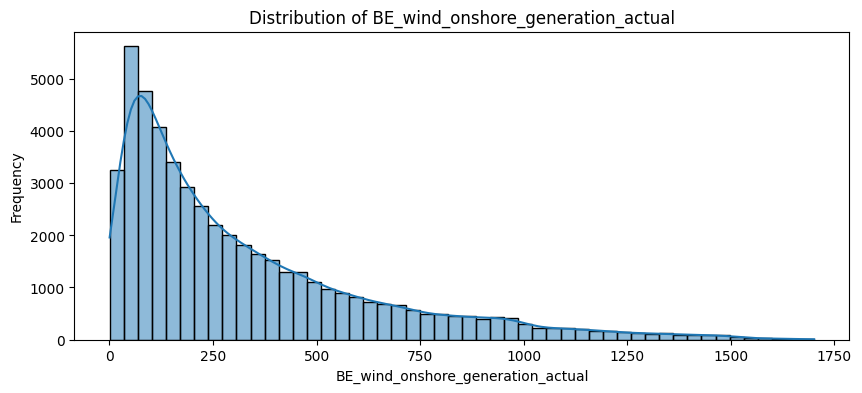

In [41]:
plt.figure(figsize=(12, 8))

def plot_df(df): # We made a function for plotting the data later on
    for col in df.columns: # Plot for each column
        if col != "hour": # No need to plot this one
            plt.figure(figsize=(10, 4)) # Making sure every graph looks similar
        
            sns.histplot(df[col], bins=50, kde=True) # We will be using an histogram
        
            plt.title(f"Distribution of {col}")
            plt.xlabel(col)
            plt.ylabel("Frequency")
        
            plt.show()
    
plot_df(df)

# We can definitely observe a right skew of our data, so we want to normalize our data as much as possible for forecasting after

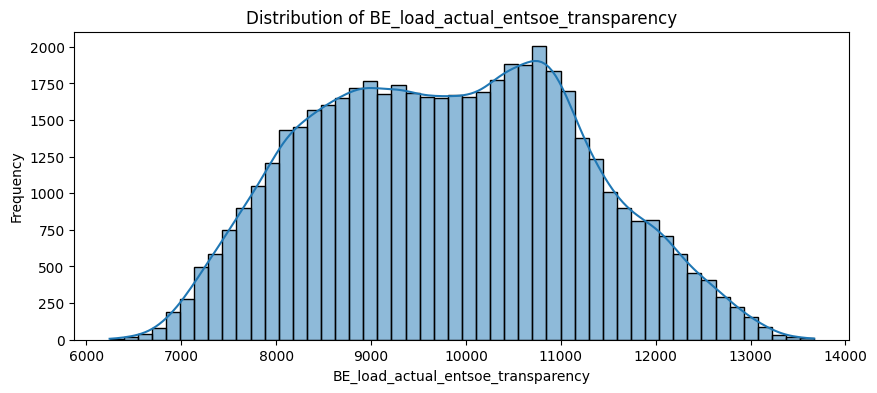

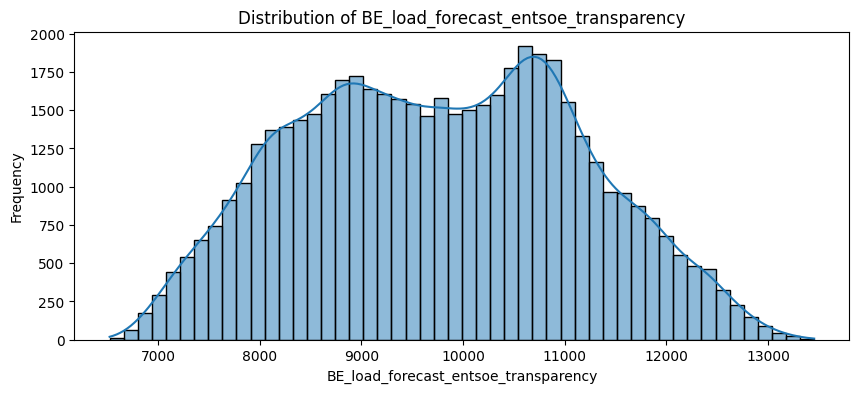

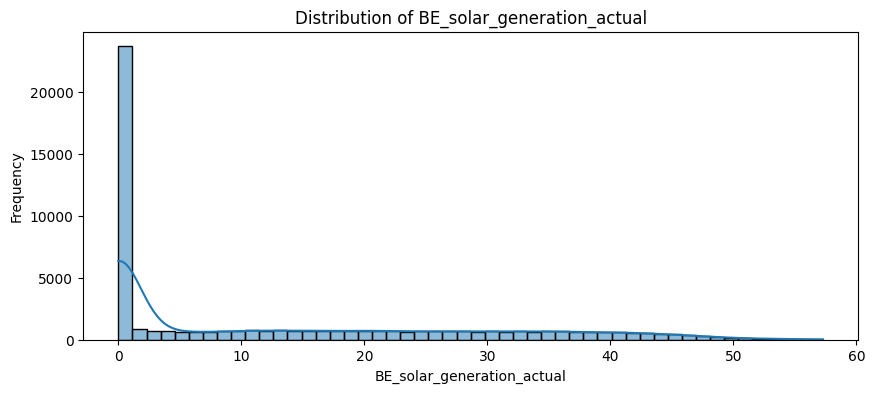

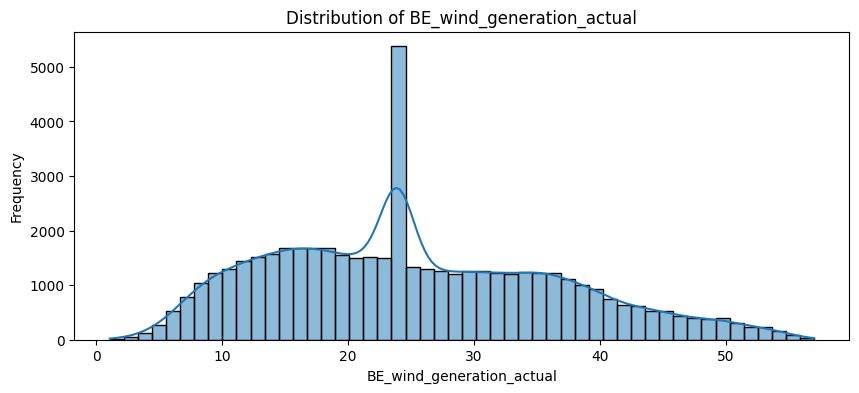

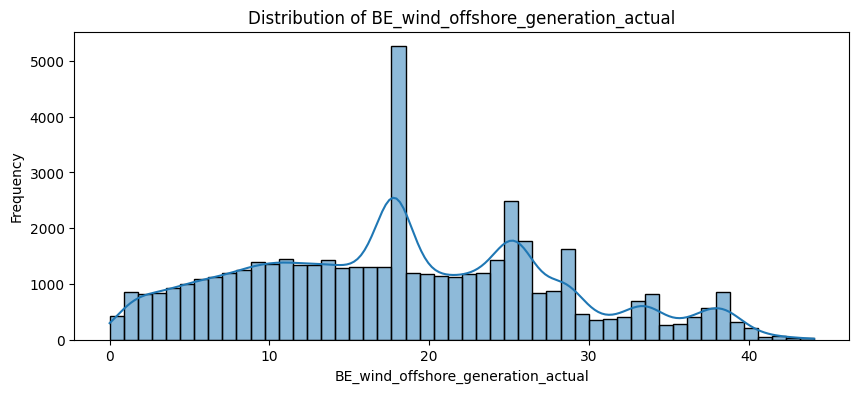

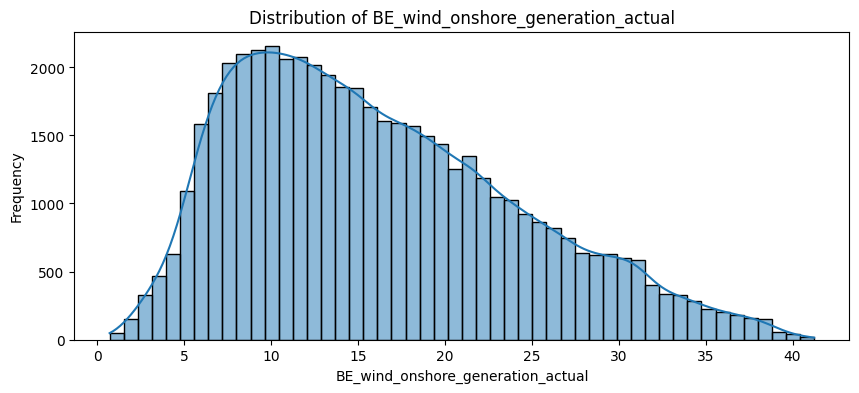

In [42]:
# We will first try to transform our data with square root and maybe log if the skewedness presists
# Also we don't need normalization for load_forecast and load_actual ENTSOE transparency as it is already looking normal

def df_normalization(df, method=""): # I used a function for playing around with the data and finding out which normalization satisfied me the most
    skewed_cols = df.skew().sort_values() # It's a function that calculates skewness and attributes a value 
    
    for col in skewed_cols[skewed_cols > 1].index: # We choose right-skewed columnns for transformation, so load actual and forecast won't be considered
        if method == "log":
            df[col] = np.log1p(df[col])
        elif method == "sqrt":
            df[col] = np.sqrt(df[col])
    
    return df 

df = df_normalization(df, method = "sqrt")
plot_df(df)

# I liked the square root transformation better, as less agressive than log. However, the user is free to use log transformation if it suits them better.

In [43]:
# In statistics, we often consider an outlier as being 3 standard deviations away from the mean
# So we use Z-score to calculate how far values are from the mean

def count_outliers(df, num):
    return (df.apply(zscore).abs() > num).sum() # We here check for values being num std times away from the mean and return as a boolean and count them

count_outliers(df, 3)

# We have 22 values in BE_wind_onshore_generation_actual that are more than 3 std away from the mean

BE_load_actual_entsoe_transparency       0
BE_load_forecast_entsoe_transparency     0
BE_solar_generation_actual               0
BE_wind_generation_actual                0
BE_wind_offshore_generation_actual       0
BE_wind_onshore_generation_actual       22
hour                                     0
dtype: int64

In [44]:
# First I quickly check on which side the extremas are, by looking at the mean and the std

df["BE_wind_onshore_generation_actual"].describe()

# As std = 8 and mean = 16, the extremas cannot be minimas (as all values > 0)

count    50401.000000
mean        16.146212
std          8.065382
min          0.700000
25%          9.707729
50%         14.807431
75%         21.473239
max         41.243787
Name: BE_wind_onshore_generation_actual, dtype: float64

In [45]:
# To get ride of these upper outliers, we will be limiting the values to 3 times the std from the mean

col = "BE_wind_onshore_generation_actual" # Avoid repeating the col name several times

wind_onshore_mean = df[col].mean()
wind_onshore_std = df[col].std()

z_score = zscore(df[col])

df.loc[z_score > 3, col] = wind_onshore_mean + 2.99*wind_onshore_std # I put 2.99 to make sure it does not overlap with my threshold being 3

count_outliers(df, 3)

BE_load_actual_entsoe_transparency      0
BE_load_forecast_entsoe_transparency    0
BE_solar_generation_actual              0
BE_wind_generation_actual               0
BE_wind_offshore_generation_actual      0
BE_wind_onshore_generation_actual       0
hour                                    0
dtype: int64

In [ ]:
# Data is cleaned, normalized and there are no more outliers, so we are ready for the next step, which is forecasting
# We will try to predict the future demand of electricity in Belgium by using ARIMA for this variable: BE_load_actual_entsoe_transparency

y = df["BE_load_actual_entsoe_transparency"].dropna() # Independent variable

split = int(0.8 * len(y)) 
train, test = y[:split], y[split:] # 80% train and 20% test

model = ARIMA(train, order=(2,1,1)) # I played around with the p, d and q for ARIMA and found these ones to give a good solution without testing big numbers
model_fit = model.fit()

# Forecast the test set
predictions = model_fit.forecast(steps=len(test))

# Compute error metrics
rmse = np.sqrt(mean_squared_error(test, predictions)) # RMSE is how far from the real observations we are 
mape = np.mean(np.abs((test - predictions) / test)) * 100 # MAPE is the percentage representation

# Print results
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Results are decent but not very convincing for forecasting what would the next days be

c:\Users\Tangu\anaconda3\envs\ENGIE\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\Tangu\anaconda3\envs\ENGIE\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\Tangu\anaconda3\envs\ENGIE\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


RMSE: 1377.65
MAPE: 11.87%


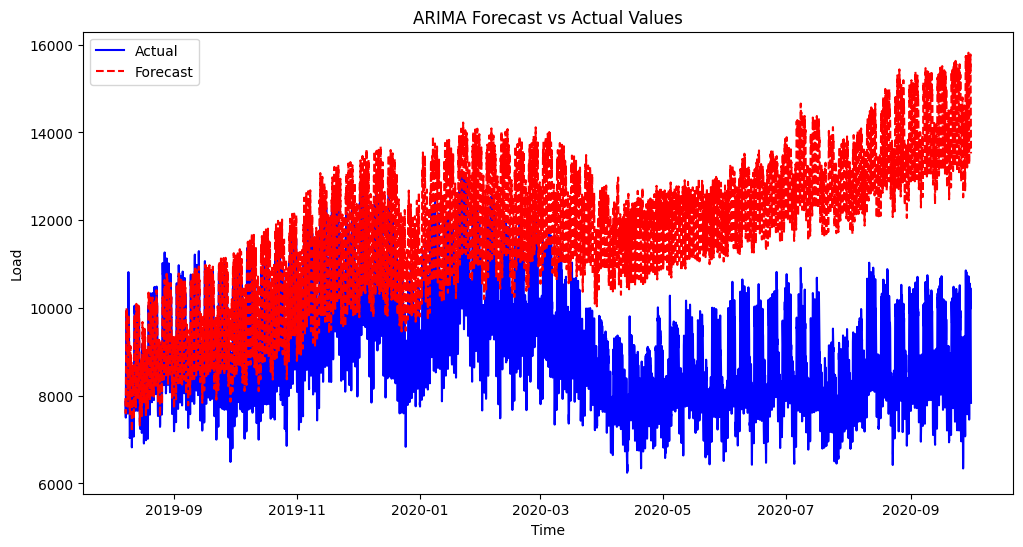

In [ ]:
# Plot of forecast vs actual values

plt.figure(figsize=(12,6))
plt.plot(test.index, test, label="Actual", color="blue")
plt.plot(test.index, predictions, label="Forecast", color="red", linestyle="dashed")
plt.xlabel("Time")
plt.ylabel("Load")
plt.title("ARIMA Forecast vs Actual Values")
plt.legend()
plt.show()

In [67]:
# I tried using SARIMAX with seasonality (date being aggregated by weeks instead of hours for identifying patterns bettrer)
# I also tried using other variables inside the model for getting better results
# Unfortunately, results were not convincing for both oh them and required much more computing power
# Instead I will try another model such as Gradient Boosting for predicting demannd

y = df["BE_load_actual_entsoe_transparency"]

df["h-1"] = df["BE_load_actual_entsoe_transparency"].shift(1) # We are using last 2 hours demand for predicting the demand of the actual hour
df["h-2"] = df["BE_load_actual_entsoe_transparency"].shift(2)

features = ["h-1", "h-2"]
X = df[features]
y = df["BE_load_actual_entsoe_transparency"]

split = int(0.8 * len(df))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Results are much more convincing, but let's see if we can do even better

RMSE: 248.72
MAPE: 2.07%


In [ ]:
y = df["BE_load_actual_entsoe_transparency"]

df["h-1"] = df["BE_load_actual_entsoe_transparency"].shift(1) # We could have used for loop and list comprehension for better code
df["h-2"] = df["BE_load_actual_entsoe_transparency"].shift(2)
df["h-3"] = df["BE_load_actual_entsoe_transparency"].shift(3)
df["h-6"] = df["BE_load_actual_entsoe_transparency"].shift(6)
df["h-12"] = df["BE_load_actual_entsoe_transparency"].shift(12)
df["h-24"] = df["BE_load_actual_entsoe_transparency"].shift(24) # last day
df["h-48"] = df["BE_load_actual_entsoe_transparency"].shift(48)
df["h-72"] = df["BE_load_actual_entsoe_transparency"].shift(72)
df["h-168"] = df["BE_load_actual_entsoe_transparency"].shift(168) # last week

# I realized the more time windows I was creating, the better my results were, so I added several

df["average_24"] = df["BE_load_actual_entsoe_transparency"].rolling(window=24).mean() # Average of the last 24 hours
df["average_168"] = df["BE_load_actual_entsoe_transparency"].rolling(window=168).mean() # Average of the last week
    
df["diff_1"] = df["BE_load_actual_entsoe_transparency"].diff(1) # Computes the current value - h-1, which improves predictivity of the model

df.dropna(inplace=True) # Just to be sure the added variables are not creating NaN

features = ["h-1", "h-2", "h-3", "h-6", "h-12", "h-24", "h-48", "h-72", "h-168", "average_24", "average_168", "diff_1"]
X = df[features]
y = df["BE_load_actual_entsoe_transparency"]

split = int(0.8 * len(df))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = xgb.XGBRegressor(objective="reg:squarederror")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Our model is already performing really well, we could still improve it using these techniques:
# Add more rolling windows for monthly average, for instance
# Add more difference of the current week and the last week, for instance
# hyperparameter tune our model, such as modifying learning rate, increasing estimators, etc..

RMSE: 42.38
MAPE: 0.27%


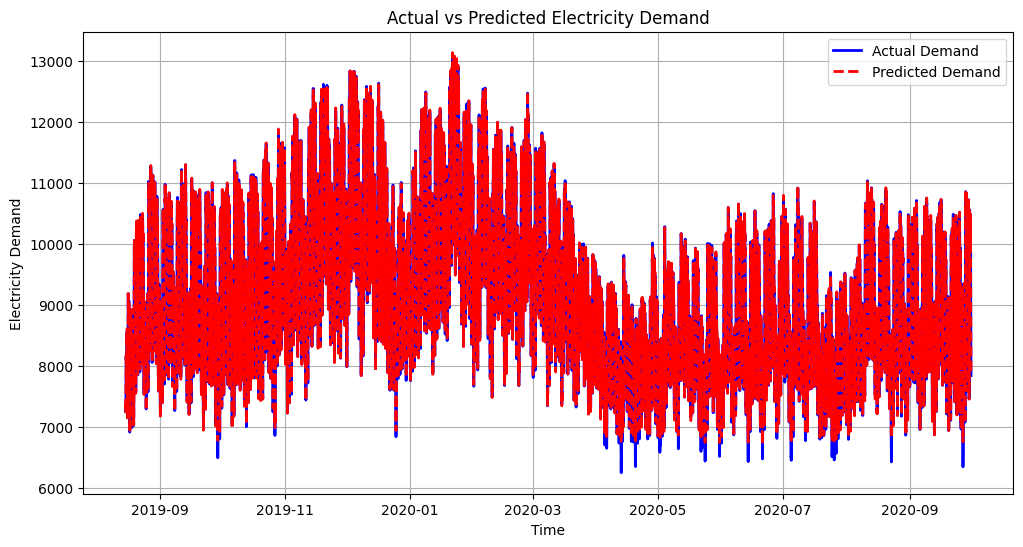

In [ ]:

# Plot current model

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual Demand", color="blue", linewidth=2)
plt.plot(y_test.index, y_pred, label="Predicted Demand", color="red", linestyle="dashed", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Electricity Demand")
plt.title("Actual vs Predicted Electricity Demand")
plt.legend()
plt.grid()
plt.show()

C:\Users\Tangu\AppData\Local\Temp\ipykernel_32040\727853041.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_timestamps = pd.date_range(start=y_test.index[-1], periods=future_steps+1, freq="H")[1:]


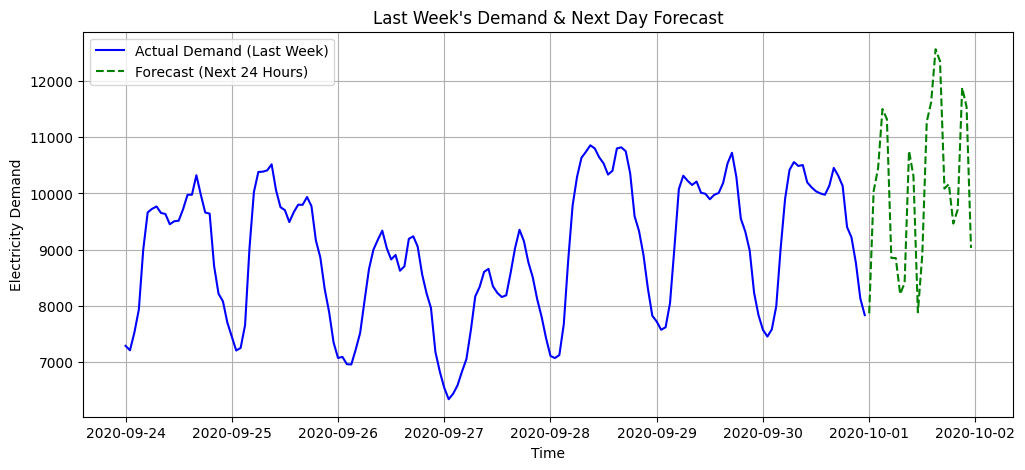

In [ ]:
# Next and last step would be to try to predict next day demand
future_steps = 24 # Next day predictions

last_week = y_test.iloc[-168:] # Use last week data for plotting

last_known_values = X_test.iloc[-1].values  

future_preds = []
for _ in range(future_steps):
    pred = model.predict(last_known_values.reshape(1, -1))[0] # Model predictions
    future_preds.append(pred)
    
    last_known_values = np.roll(last_known_values, -1)
    last_known_values[-1] = pred  

future_timestamps = pd.date_range(start=y_test.index[-1], periods=future_steps+1, freq="H")[1:]

# Plot actual demand of last week
plt.figure(figsize=(12, 5))
plt.plot(last_week.index, last_week, label="Actual Demand (Last Week)", color="blue")

# Plot forecasted demand
plt.plot(future_timestamps, future_preds, label="Forecast (Next 24 Hours)", color="green", linestyle="dashed")

plt.xlabel("Time")
plt.ylabel("Electricity Demand")
plt.title("Last Week's Demand & Next Day Forecast")
plt.legend()
plt.grid()
plt.show()